In [17]:
# ================== Step 1: Load and Clean ==================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('loan_data.csv')


In [18]:
# Summary statistics
print(df.info())
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   loan_id       1000 non-null   int64  
 1   age           1000 non-null   int64  
 2   income        949 non-null    float64
 3   loan_amount   1000 non-null   int64  
 4   credit_score  1000 non-null   int64  
 5   default       1000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 47.0 KB
None


,loan_id,age,income,loan_amount,credit_score,default
count,1000.000000,1000.000000,949.000000,1000.000000,1000.000000,1000.000000
mean,1500.500000,43.862000,50026.168599,39376.065000,569.330000,0.202000
std,288.819436,15.350133,15405.850529,106044.548426,158.685734,0.401693
min,1001.000000,18.000000,4424.000000,-9108.000000,300.000000,0.000000
25%,1250.750000,30.000000,40001.000000,9812.250000,428.750000,0.000000
50%,1500.500000,44.000000,49712.000000,15645.500000,564.000000,0.000000
75%,1750.250000,58.000000,60565.000000,21816.500000,708.000000,0.000000
max,2000.000000,69.000000,93872.000000,500000.000000,849.000000,1.000000


In [19]:
# Handle missing values - fill 'income' with median
df['income'] = df['income'].fillna(df['income'].median())

# Verify after imputation
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   loan_id       1000 non-null   int64  
 1   age           1000 non-null   int64  
 2   income        1000 non-null   float64
 3   loan_amount   1000 non-null   int64  
 4   credit_score  1000 non-null   int64  
 5   default       1000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 47.0 KB
None


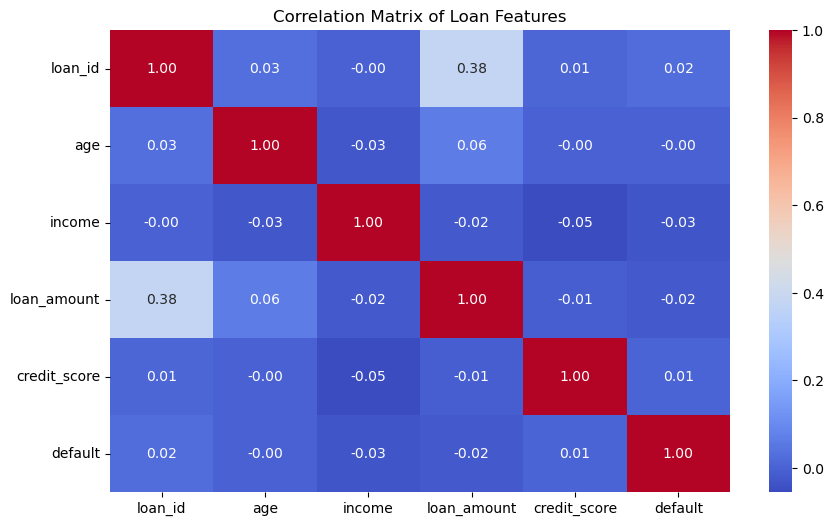

In [20]:
# ================== Step 2: Visualizing Correlations ==================
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Loan Features")
plt.show()


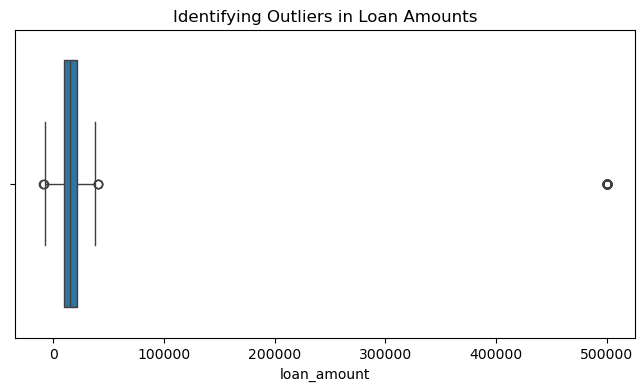

In [21]:
# ================== Step 3: Outlier Detection ==================
# Before clipping
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['loan_amount'])
plt.title("Identifying Outliers in Loan Amounts")
plt.show()

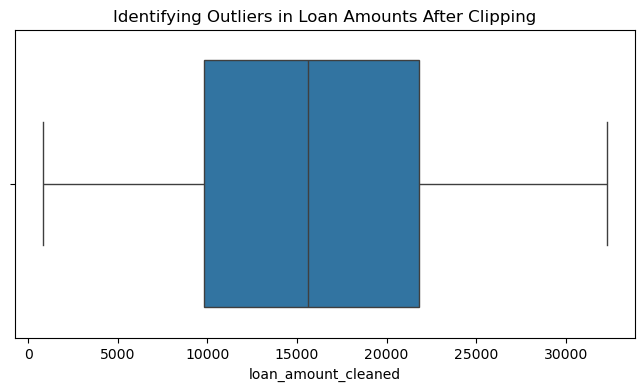

In [22]:
# Clipping outliers to 5th and 95th percentile
qu_limit = df['loan_amount'].quantile(0.93)   # we can adjust the quantile value as per the requirements
ql_limit = df['loan_amount'].quantile(0.05)
df['loan_amount_cleaned'] = df['loan_amount'].clip(upper=qu_limit, lower=ql_limit)

# After clipping
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['loan_amount_cleaned'])
plt.title("Identifying Outliers in Loan Amounts After Clipping")
plt.show()

In [23]:
# ================== Step 4: Feature Engineering ==================
# Create Debt-to-Income Ratio
df['dti_ratio'] = df['loan_amount_cleaned'] / df['income']

# Categorize credit scores into 'Risk Levels'
bins = [300, 580, 670, 740, 850]
labels = ['High Risk', 'Fair', 'Good', 'Excellent']
df['risk_category'] = pd.cut(df['credit_score'], bins=bins, labels=labels)

# Preview new features
print(df[['income', 'dti_ratio', 'risk_category']].head())


    income  dti_ratio risk_category
0  49712.0   0.231634     High Risk
1  49712.0   0.536551          Good
2  49712.0   0.226645     High Risk
3  49712.0   0.232560     High Risk
4  49712.0   0.388558     High Risk


In [24]:
# ================== Step 5: Findings Summary ==================
# Quick analysis of default rates by risk category
summary = df.groupby('risk_category', observed=False)['default'].mean() * 100
print(f"Default Percentage by Category:\n{summary}")

Default Percentage by Category:
risk_category
High Risk    19.311663
Fair         20.779221
Good         19.259259
Excellent    22.994652
Name: default, dtype: float64


# Project Summary
- Missing Values: Handling using median imputation to maintain data distribution.
- Outliers: Identified extreme loan_amount values that could skew model training.
- Feature: Engineered dti_ratio, which is often more predictive than the income alone.
- Insight: Higher risk categories show a clear correlation with actual defaults.